# INTACT — Local LSTM Autoencoder Pipeline v4
**Stealthy replay attack design based on:**
- Statistical window selection [Shen & Qin, 2024]
- Cross-fade boundary blending [Erba et al., 2020]
- Full multi-variable injection preserving AC power flow constraints

**Fixes in v4:**
- Hour-exclusion in similarity search prevents 0.0000 score from same-hour synthetic data
- WINDOW_LEN corrected to 48 (4 hours) with correct comment
- Zone 1 targets changed to evening peak load (zone has no DER)
- 3-4 attack events per zone for statistical reliability
- Font changed to DejaVu Serif (Times New Roman not available on server)
- Optuna isolated with file-based skip

**Cell order:** CONFIG → IMPORTS → ATTACK FUNCTIONS → DATA GENERATION → VERIFY → PREPROCESS → OPTUNA (once) → TRAIN → TEST → SUMMARY → FIGURES

## 0 — CONFIG
**Change only ZONE_ID. Everything else is fixed.**

In [1]:
# ─── Change only this ────────────────────────────────────────────────────────
ZONE_ID      = 'zone4'     # zone1 / zone2 / zone3 / zone4
# ─────────────────────────────────────────────────────────────────────────────

WINDOW_SIZE  = 30          # 30 timesteps = 2.5 hours per LSTM sequence
WINDOW_LEN   = 48          # 4 hours = 48 rows — attack window size
                           # After 12-step blend each side: 24 clean labeled rows
BLEND_STEPS  = 12          # cross-fade rows at each attack boundary (1 hour each side)
NOISE_STD    = 0.002       # Gaussian sensor noise std (pu) — realistic for distribution sensors
N_TRIALS     = 30          # Optuna hyperparameter search trials
EPOCHS       = 50
BATCH_SIZE   = 32
RANDOM_SEED  = 42
PERCENTILES  = [95, 96, 97, 98, 99, 99.1, 99.2,
                99.3, 99.4, 99.5, 99.6, 99.7, 99.8, 99.9]
DROP_COLS    = ['V_bus0', 'P_bus0', 'Q_bus0', 'THETA_bus0']  # slack bus — constant

TRAIN_RAW    = f'{ZONE_ID}_train.csv'
TEST_RAW     = f'{ZONE_ID}_test.csv'
TRAIN_NOISY  = f'{ZONE_ID}_train_noisy.csv'
TEST_STEALTHY= f'{ZONE_ID}_test_stealthy.csv'
PARAMS_FILE  = f'results/{ZONE_ID}_best_params.txt'

import os
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)
print(f'Zone          : {ZONE_ID}')
print(f'Train input   : {TRAIN_NOISY}')
print(f'Test input    : {TEST_STEALTHY}')
print(f'Optuna params : {PARAMS_FILE}')

Zone          : zone4
Train input   : zone4_train_noisy.csv
Test input    : zone4_test_stealthy.csv
Optuna params : results/zone4_best_params.txt


## 1 — IMPORTS

In [2]:
import warnings, os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                      TimeDistributed, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              classification_report)
import joblib

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# IEEE paper style — DejaVu Serif used (Times New Roman not available on Linux server)
matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'font.size'        : 8,
    'axes.titlesize'   : 8,
    'axes.labelsize'   : 8,
    'xtick.labelsize'  : 7,
    'ytick.labelsize'  : 7,
    'legend.fontsize'  : 7,
    'axes.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 300,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})
print(f'TF {tf.__version__} | Optuna {optuna.__version__}')

I0000 00:00:1777949229.879809 3656981 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777949229.932726 3656981 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777949231.076760 3656981 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF 2.21.0 | Optuna 4.8.0


## 2 — ATTACK FUNCTIONS
Context-aware stealthy replay attack implementation.
Based on: Shen & Qin (2024), Erba et al. (2020), Gao et al. (2022)

In [3]:
def row(day, hour):
    """Convert day (1-based) and hour (0-23) to dataset row index."""
    return (day - 1) * 288 + hour * 12


def add_noise(df, std, seed=42):
    """Add Gaussian sensor measurement noise. Skips timestamp and label columns."""
    np.random.seed(seed)
    df = df.copy()
    feat_cols = [c for c in df.columns if c not in ['timestamp', 'attack_label']]
    df[feat_cols] += np.random.normal(0, std, df[feat_cols].shape)
    return df


def find_similar_window(df, target_start, target_end, feat_cols):
    """
    Step 1 of stealthy attack: Statistical Window Selection.

    Finds the historical source window that minimises the normalised mean
    absolute deviation in both mean and standard deviation relative to the
    target window — simulating an attacker who recorded data during a
    statistically similar operating condition (e.g. partial cloud cover)
    rather than naively replaying midnight data.

    Key fix: windows within ±2 hours of the target hour are excluded.
    Synthetic PandaPower data produces near-identical values at the same
    hour on different days, which would give a 0.0000 similarity score
    and effectively make the attack a no-op (source == target).
    Excluding same-hour windows forces the algorithm to find data from
    a different part of the day that is nonetheless statistically similar.

    Constraints enforced:
      - Minimum 3 days (864 rows) separation from target
      - Source hour must differ from target hour by more than 2 hours

    Based on: Shen & Qin (2024) — statistical divergence minimisation.

    Returns: (best_source_start, best_source_end, similarity_score)
    """
    window_len    = target_end - target_start
    target_vals   = df[feat_cols].iloc[target_start:target_end].values
    target_mean   = target_vals.mean(axis=0)
    target_std    = target_vals.std(axis=0) + 1e-9
    target_hour   = (target_start % 288) // 12

    MIN_SEP = 288 * 3  # 3 days minimum separation

    best_score = np.inf
    best_start = 0

    for start in range(0, target_start - MIN_SEP, 12):
        # --- FIX: exclude windows from same hour (±2h) of day ---
        cand_hour = (start % 288) // 12
        if abs(cand_hour - target_hour) <= 2:
            continue

        cand = df[feat_cols].iloc[start:start + window_len].values
        if len(cand) < window_len:
            continue

        score = (
            (np.abs(cand.mean(axis=0) - target_mean) / target_std).mean() +
            (np.abs(cand.std(axis=0)  - target_std)  / target_std).mean()
        )
        if score < best_score:
            best_score = score
            best_start = start

    return best_start, best_start + window_len, best_score


def inject_replay_stealthy(df, source_start, source_end,
                            target_start, target_end, blend_steps=12):
    """
    Step 2 of stealthy attack: Cross-Fade Boundary Blending.

    Replaces the full multi-variable state [P, Q, |V|, theta] at the
    target window with historical values from the source window.
    Full multi-variable replacement preserves local AC power flow
    consistency — the local LSTM reconstructs the sequence with low error
    because all four features are internally consistent.

    Boundaries are smoothed over blend_steps timesteps (cross-fade in and
    cross-fade out) to eliminate the sharp temporal discontinuity that
    naive hard-cut injection creates at the injection boundary.

    Only the unblended middle portion is labeled as attack=1.
    Blended boundary rows are transitional and left as attack=0.

    Based on: Erba et al. (2020) — temporal correlation preservation.
    """
    df = df.copy()
    if 'attack_label' not in df.columns:
        df['attack_label'] = 0

    feat_cols = [c for c in df.columns if c not in ['timestamp', 'attack_label']]
    src_vals  = df[feat_cols].iloc[source_start:source_end].values.copy()
    n         = target_end - target_start
    injected  = src_vals[:n].copy()
    bs        = min(blend_steps, n // 4)

    # Cross-fade in: real → historical (alpha: 0 → 1)
    for i in range(bs):
        alpha = i / bs
        real  = df[feat_cols].iloc[target_start + i].values
        injected[i] = (1 - alpha) * real + alpha * src_vals[i]

    # Cross-fade out: historical → real (alpha: 1 → 0)
    for i in range(bs):
        alpha = 1.0 - (i / bs)
        idx   = n - bs + i
        real  = df[feat_cols].iloc[target_start + idx].values
        injected[idx] = alpha * src_vals[idx] + (1 - alpha) * real

    for ci, col in enumerate(feat_cols):
        df.iloc[target_start:target_end, df.columns.get_loc(col)] = injected[:, ci]

    # Label only clean middle as attack
    mid_s = target_start + bs
    mid_e = target_end   - bs
    if mid_e > mid_s:
        df.iloc[mid_s:mid_e, df.columns.get_loc('attack_label')] = 1
    return df


print('Attack functions defined:')
print('  row()                    -- row index helper')
print('  add_noise()              -- Gaussian sensor noise')
print('  find_similar_window()    -- Step 1: statistical window selection')
print('  inject_replay_stealthy() -- Step 2: cross-fade boundary blending')

Attack functions defined:
  row()                    -- row index helper
  add_noise()              -- Gaussian sensor noise
  find_similar_window()    -- Step 1: statistical window selection
  inject_replay_stealthy() -- Step 2: cross-fade boundary blending


## 3 — DATA GENERATION
Generates noisy training data and stealthy test data.
**Re-run this cell if you change ZONE_ID, WINDOW_LEN, BLEND_STEPS, or NOISE_STD.**

In [4]:
# ─── TARGET WINDOWS per zone ──────────────────────────────────────────────────
#
# Zone 1 (no DER): attack evening peak load (18:00-20:00)
#   Attacker suppresses load readings during high-demand evening.
#   Neighbors with DER still show correct solar ramp-down -> spatial mismatch.
#
# Zones 2,3,4 (with DER): attack peak solar noon (10:00-14:00)
#   Attacker suppresses DER generation reports during clear-sky peak.
#   Neighboring zones still show correct solar generation -> spatial mismatch.
#
# Rule: source window is found automatically by find_similar_window()
#   - Minimum 3 days (864 rows) separation from target
#   - Source hour must differ from target hour by >2 hours (avoids 0.0000 score)

TARGET_WINDOWS = {
    'zone1': [
        row(6,  19),   # day 6  19:00 — evening peak load
        row(9,  18),   # day 9  18:00 — evening peak load
        row(12, 20),   # day 12 20:00 — late evening peak
    ],
    'zone2': [
        row(5,  12),   # day 5  12:00 — peak solar noon
        row(8,  13),   # day 8  13:00 — peak solar afternoon
        row(10, 10),   # day 10 10:00 — morning solar peak
        row(12, 11),   # day 12 11:00 — late morning peak
    ],
    'zone3': [
        row(6,  11),   # day 6  11:00 — peak solar
        row(9,  12),   # day 9  12:00 — peak solar noon
        row(11, 13),   # day 11 13:00 — afternoon solar
        row(13, 10),   # day 13 10:00 — morning solar
    ],
    'zone4': [
        row(5,  13),   # day 5  13:00 — DER_3 peak (0.6 MW, largest)
        row(8,  12),   # day 8  12:00 — peak solar noon
        row(11, 14),   # day 11 14:00 — afternoon solar
        row(13, 11),   # day 13 11:00 — late morning peak
    ],
}

# ─── 3A: Noisy training data ──────────────────────────────────────────────────
print('Generating noisy training data...')
df_train_raw   = pd.read_csv(TRAIN_RAW, parse_dates=['timestamp'])
df_train_noisy = add_noise(df_train_raw, std=NOISE_STD, seed=RANDOM_SEED)
df_train_noisy.to_csv(TRAIN_NOISY, index=False)
print(f'  Saved: {TRAIN_NOISY}  shape={df_train_noisy.shape}')

# ─── 3B: Stealthy test data ───────────────────────────────────────────────────
print(f'\nGenerating stealthy test data for {ZONE_ID}...')
df_test = pd.read_csv(TEST_RAW, parse_dates=['timestamp'])
df_test['attack_label'] = 0

feat_cols = [c for c in df_test.columns if c not in ['timestamp', 'attack_label']]
targets   = TARGET_WINDOWS.get(ZONE_ID, [])

print(f'\n  Target windows:')
for t in targets:
    print(f'    rows {t:4d} to {t+WINDOW_LEN:4d}  '
          f'(day {t//288 + 1:2d}, hour {(t%288)//12:02d}:00)')

print(f'\n  Searching for statistically similar source windows...')
print(f'  (Same-hour windows excluded to prevent 0.0000 score in synthetic data)')
source_windows = []
for tgt_start in targets:
    tgt_end = tgt_start + WINDOW_LEN
    src_start, src_end, score = find_similar_window(
        df_test, tgt_start, tgt_end, feat_cols
    )
    source_windows.append((src_start, src_end, tgt_start, tgt_end))
    src_day  = src_start // 288 + 1
    src_hour = (src_start % 288) // 12
    tgt_day  = tgt_start // 288 + 1
    tgt_hour = (tgt_start % 288) // 12
    print(f'    Target day {tgt_day:2d} {tgt_hour:02d}:00 -> '
          f'Source day {src_day:2d} {src_hour:02d}:00  '
          f'(score={score:.4f})')
    if score < 0.01:
        print(f'    WARNING: Score {score:.4f} is very low — '
              f'source may be too similar to target (possible no-op injection)')

# ─── Inject attacks ───────────────────────────────────────────────────────────
print(f'\n  Injecting {len(source_windows)} stealthy replay attacks...')
df_stealthy = df_test.copy()
for i, (ss, se, ts, te) in enumerate(source_windows):
    df_stealthy = inject_replay_stealthy(
        df_stealthy, ss, se, ts, te, blend_steps=BLEND_STEPS
    )
    n_atk = (df_stealthy['attack_label'] == 1).sum()
    print(f'  Attack {i+1} injected. Attack rows so far: {n_atk}')

# ─── Add noise to test ────────────────────────────────────────────────────────
df_stealthy = add_noise(df_stealthy, std=NOISE_STD, seed=RANDOM_SEED + 1)
df_stealthy.to_csv(TEST_STEALTHY, index=False)

total  = len(df_stealthy)
n_atk  = (df_stealthy['attack_label'] == 1).sum()
print(f'\nSaved: {TEST_STEALTHY}')
print(f'  Total rows    : {total}')
print(f'  Attack rows   : {n_atk} ({n_atk/total*100:.1f}%)')
print(f'  Normal rows   : {total - n_atk}')
print(f'  Blend steps   : {BLEND_STEPS} ({BLEND_STEPS*5} min smooth transition each side)')
print(f'  Clean labeled : {WINDOW_LEN - 2*BLEND_STEPS} rows per attack event')

Generating noisy training data...
  Saved: zone4_train_noisy.csv  shape=(8064, 33)

Generating stealthy test data for zone4...

  Target windows:
    rows 1308 to 1356  (day  5, hour 13:00)
    rows 2160 to 2208  (day  8, hour 12:00)
    rows 3048 to 3096  (day 11, hour 14:00)
    rows 3588 to 3636  (day 13, hour 11:00)

  Searching for statistically similar source windows...
  (Same-hour windows excluded to prevent 0.0000 score in synthetic data)
    Target day  5 13:00 -> Source day  1 10:00  (score=1.6802)
    Target day  8 12:00 -> Source day  5 08:00  (score=4.1514)
    Target day 11 14:00 -> Source day  1 08:00  (score=0.4913)
    Target day 13 11:00 -> Source day  5 05:00  (score=0.6050)

  Injecting 4 stealthy replay attacks...
  Attack 1 injected. Attack rows so far: 24
  Attack 2 injected. Attack rows so far: 48
  Attack 3 injected. Attack rows so far: 72
  Attack 4 injected. Attack rows so far: 96

Saved: zone4_test_stealthy.csv
  Total rows    : 4032
  Attack rows   : 96 (2

## 4 — VERIFY ATTACK STEALTHINESS
Visual sanity check before training.
Panel (a): source vs target vs injected signal — values should overlap.
Panel (b): attack in context — no sharp discontinuity at boundaries.

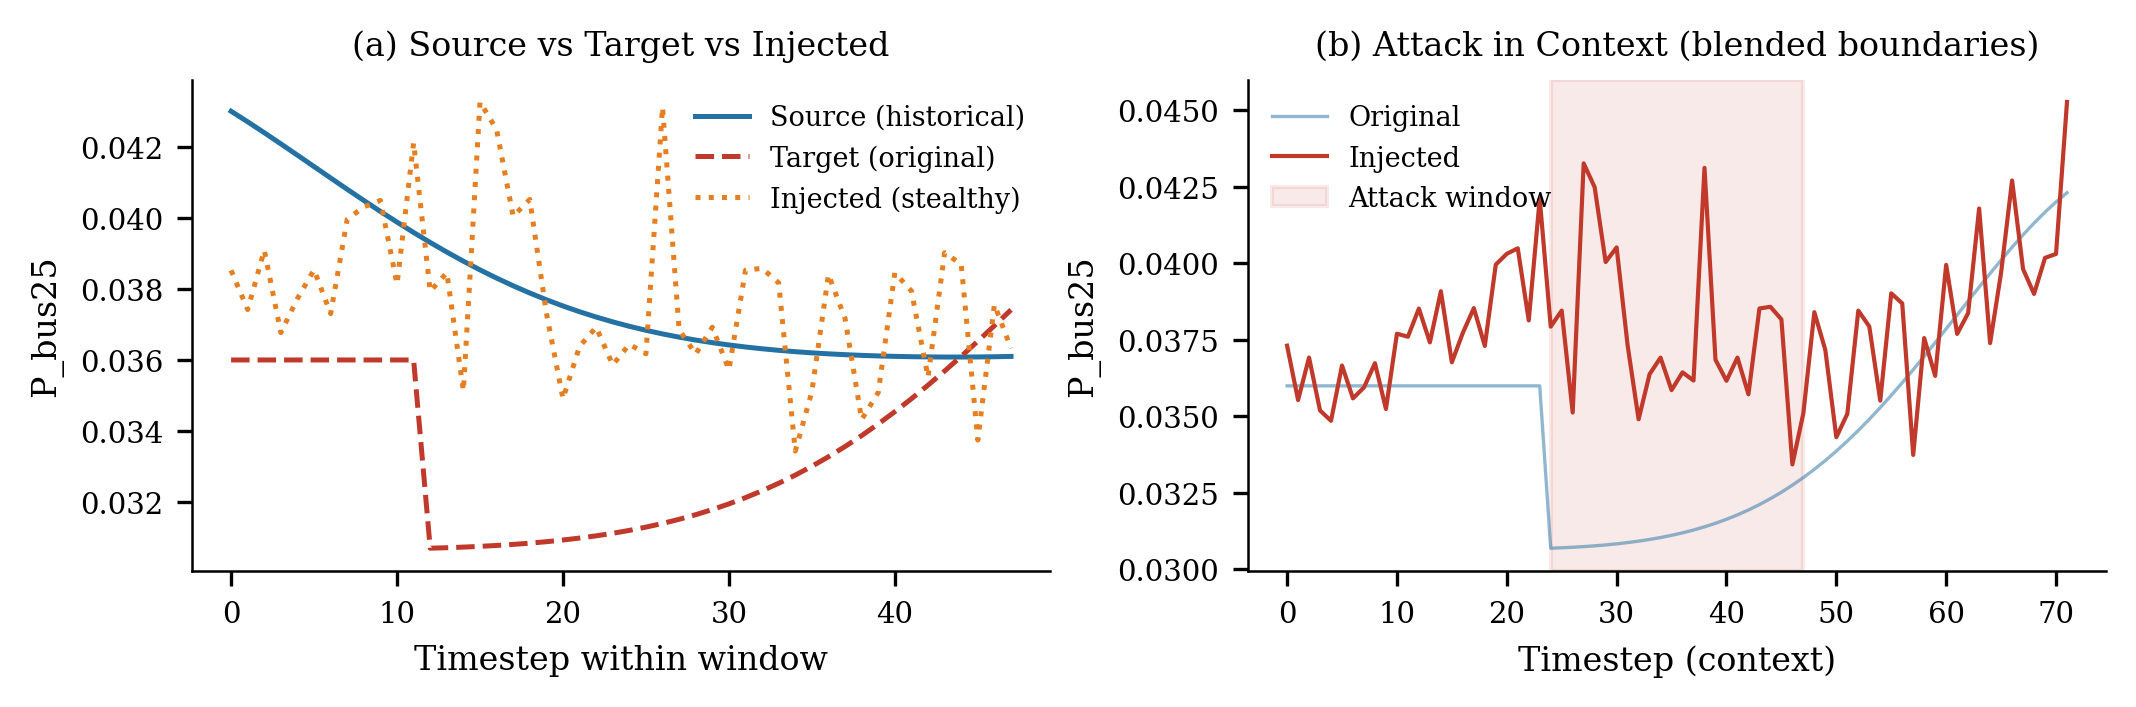

Saved: results/zone4_fig_attack_design.pdf

CHECK panel (a): source and target should overlap in value range
CHECK panel (a): injected line should blend at edges, not jump
CHECK panel (b): no sharp discontinuity at pink shaded region boundaries

Similarity scores (lower = more similar = more stealthy):
  Attack 1: score=1.6802  src day 1 10:00 -> tgt day 5 13:00
  Attack 2: score=4.1514  src day 5 08:00 -> tgt day 8 12:00
  Attack 3: score=0.4913  src day 1 08:00 -> tgt day 11 14:00
  Attack 4: score=0.6050  src day 5 05:00 -> tgt day 13 11:00


In [5]:
if source_windows:
    ss, se, ts, te = source_windows[0]
    p_cols = [c for c in feat_cols if c.startswith('P_')]
    p_col  = p_cols[0] if p_cols else feat_cols[0]
    ctx_s  = max(0, ts - 12)
    ctx_e  = min(len(df_stealthy), te + 12)

    fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.4))

    # Panel A: source vs target vs injected
    ax = axes[0]
    ax.plot(range(WINDOW_LEN), df_test[p_col].iloc[ss:se].values,
            color='#2471a3', lw=1.2, label='Source (historical)')
    ax.plot(range(WINDOW_LEN), df_test[p_col].iloc[ts:te].values,
            color='#c0392b', lw=1.2, ls='--', label='Target (original)')
    ax.plot(range(WINDOW_LEN), df_stealthy[p_col].iloc[ts:te].values,
            color='#e67e22', lw=1.2, ls=':', label='Injected (stealthy)')
    ax.set_xlabel('Timestep within window')
    ax.set_ylabel(f'{p_col}')
    ax.set_title('(a) Source vs Target vs Injected', fontsize=8)
    ax.legend(frameon=False, fontsize=6.5)

    # Panel B: attack in context
    ax2 = axes[1]
    orig_ctx   = df_test[p_col].iloc[ctx_s:ctx_e].values
    atk_ctx    = df_stealthy[p_col].iloc[ctx_s:ctx_e].values
    labels_ctx = df_stealthy['attack_label'].iloc[ctx_s:ctx_e].values

    ax2.plot(range(len(orig_ctx)), orig_ctx,
             color='#2471a3', lw=0.8, alpha=0.5, label='Original')
    ax2.plot(range(len(atk_ctx)),  atk_ctx,
             color='#c0392b', lw=1.0, label='Injected')

    atk_idx = np.where(labels_ctx == 1)[0]
    if len(atk_idx):
        ax2.axvspan(atk_idx[0], atk_idx[-1], color='#c0392b',
                    alpha=0.1, label='Attack window')

    ax2.set_xlabel('Timestep (context)')
    ax2.set_ylabel(f'{p_col}')
    ax2.set_title('(b) Attack in Context (blended boundaries)', fontsize=8)
    ax2.legend(frameon=False, fontsize=6.5)

    plt.tight_layout()
    plt.savefig(f'results/{ZONE_ID}_fig_attack_design.pdf')
    plt.savefig(f'results/{ZONE_ID}_fig_attack_design.png')
    plt.show()
    print('Saved: results/{}_fig_attack_design.pdf'.format(ZONE_ID))
    print()
    print('CHECK panel (a): source and target should overlap in value range')
    print('CHECK panel (a): injected line should blend at edges, not jump')
    print('CHECK panel (b): no sharp discontinuity at pink shaded region boundaries')
    print()
    # Print similarity scores for all events
    print('Similarity scores (lower = more similar = more stealthy):')
    for i, (ss, se, ts, te) in enumerate(source_windows):
        _, _, score = find_similar_window(df_test, ts, te, feat_cols)
        print(f'  Attack {i+1}: score={score:.4f}  '
              f'src day {ss//288+1} {(ss%288)//12:02d}:00 -> '
              f'tgt day {ts//288+1} {(ts%288)//12:02d}:00')

## 5 — LOAD AND PREPROCESS

In [6]:
df_train = pd.read_csv(TRAIN_NOISY,   parse_dates=['timestamp']).set_index('timestamp')
df_test  = pd.read_csv(TEST_STEALTHY, parse_dates=['timestamp']).set_index('timestamp')

test_labels = df_test['attack_label'].values.astype(int)
df_test = df_test.drop(columns=['attack_label'])

# Drop slack bus columns (Bus 0 — constant voltage, zero variance, causes NaN)
drop = [c for c in DROP_COLS if c in df_train.columns]
df_train = df_train.drop(columns=drop)
df_test  = df_test.drop(columns=drop)

# Drop any remaining zero-variance columns
zv = df_train.columns[df_train.std() < 1e-9]
if len(zv):
    print(f'Dropping zero-variance columns: {list(zv)}')
    df_train = df_train.drop(columns=zv)
    df_test  = df_test.drop(columns=zv)

assert list(df_train.columns) == list(df_test.columns), \
    'ERROR: Train and test columns do not match!'

N_FEATURES = df_train.shape[1]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train.values)
test_scaled  = scaler.transform(df_test.values)
joblib.dump(scaler, f'models/{ZONE_ID}_scaler.pkl')

def make_sequences(data, w):
    return np.array([data[i:i+w] for i in range(len(data) - w)])

X_train = make_sequences(train_scaled, WINDOW_SIZE)
X_test  = make_sequences(test_scaled,  WINDOW_SIZE)

# Window labeled attack=1 if ANY of its timesteps is an attack row
y_test = np.array([
    1 if test_labels[i:i+WINDOW_SIZE].sum() > 0 else 0
    for i in range(len(test_labels) - WINDOW_SIZE)
])

print(f'Features        : {N_FEATURES}')
print(f'X_train         : {X_train.shape}')
print(f'X_test          : {X_test.shape}')
print(f'Attack windows  : {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)')
print(f'Scaler saved    : models/{ZONE_ID}_scaler.pkl')

Features        : 32
X_train         : (8034, 30, 32)
X_test          : (4002, 30, 32)
Attack windows  : 212 / 4002 (5.3%)
Scaler saved    : models/zone4_scaler.pkl


## 6 — OPTUNA HYPERPARAMETER SEARCH
> **Runs ONCE per zone automatically.** Results saved to `results/zoneX_best_params.txt`.
> On all subsequent runs this cell is skipped — loads saved params instead.
> Set `FORCE_RETUNE = True` to re-run Optuna from scratch.

In [7]:
FORCE_RETUNE = False  # set True to re-run Optuna

if os.path.exists(PARAMS_FILE) and not FORCE_RETUNE:
    print(f'Params file found: {PARAMS_FILE}')
    print('Skipping Optuna — loading saved params.')
    print('Set FORCE_RETUNE = True above to re-run.')
else:
    val_split  = int(len(X_train) * 0.9)
    X_tr, X_val = X_train[:val_split], X_train[val_split:]

    def build_trial_model(trial):
        u1 = trial.suggest_categorical('lstm_units_1', [32, 64, 128])
        u2 = trial.suggest_categorical('lstm_units_2', [16, 32, 64])
        dr = trial.suggest_float('dropout_rate', 0.0, 0.3, step=0.1)
        lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
        x   = LSTM(u1, activation='tanh', return_sequences=True)(inp)
        x   = Dropout(dr)(x)
        x   = LSTM(u2, activation='tanh', return_sequences=False)(x)
        x   = RepeatVector(WINDOW_SIZE)(x)
        x   = LSTM(u2, activation='tanh', return_sequences=True)(x)
        x   = Dropout(dr)(x)
        x   = LSTM(u1, activation='tanh', return_sequences=True)(x)
        out = TimeDistributed(Dense(N_FEATURES))(x)
        m   = Model(inp, out)
        m.compile(optimizer=Adam(lr), loss='mse')
        return m

    def objective(trial):
        tf.keras.backend.clear_session()
        m  = build_trial_model(trial)
        cb = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=0)
        m.fit(X_tr, X_tr, epochs=20, batch_size=BATCH_SIZE,
              validation_data=(X_val, X_val), callbacks=[cb], verbose=0)
        return m.evaluate(X_val, X_val, verbose=0)

    print(f'Running Optuna: {N_TRIALS} trials...')
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_params
    best['best_val_mse'] = study.best_value

    with open(PARAMS_FILE, 'w') as f:
        f.write(f'Optuna Best Params — {ZONE_ID}\n')
        f.write('=' * 40 + '\n')
        for k, v in best.items():
            f.write(f'{k}: {v}\n')

    print(f'Best params saved: {PARAMS_FILE}')
    for k, v in best.items():
        print(f'  {k}: {v}')

Running Optuna: 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

E0000 00:00:1777949234.339839 3656981 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1777949234.339880 3656981 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1777949234.339885 3656981 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: 1b97c3778d1a
I0000 00:00:1777949234.339891 3656981 cuda_diagnostics.cc:183] hostname: 1b97c3778d1a
I0000 00:00:1777949234.339989 3656981 cuda_diagnostics.cc:190] libcuda reported version is: 580.126.9
I0000 00:00:1777949234.340013 3656981 cuda_diagnostics.cc:194] kernel reported version is: 580.126.9
I0000 00:00:1777949234.340017 3656981 cuda_diagnostics.cc:284] kernel version seems to match DSO: 580.126.9
E0000 00:00:1777949237.463266 3656981 util.cc:131] oneDNN supports DT_INT32 only

Best params saved: results/zone4_best_params.txt
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.00906880091488003
  best_val_mse: 0.0023400152567774057


## 7 — TRAIN FINAL MODEL

In [8]:
# Load best params from txt file
best_params = {}
with open(PARAMS_FILE, 'r') as f:
    for line in f:
        if ':' not in line or 'Optuna' in line or '===' in line:
            continue
        k, v = line.strip().split(':', 1)
        v = v.strip()
        try:    v = int(v)
        except:
            try: v = float(v)
            except: pass
        best_params[k.strip()] = v

print(f'Loaded hyperparameters from: {PARAMS_FILE}')
for k, v in best_params.items():
    print(f'  {k}: {v}')

tf.keras.backend.clear_session()
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

u1 = int(best_params['lstm_units_1'])
u2 = int(best_params['lstm_units_2'])
dr = float(best_params['dropout_rate'])
lr = float(best_params['learning_rate'])

inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
x   = LSTM(u1, activation='tanh', return_sequences=True)(inp)
x   = Dropout(dr)(x)
x   = LSTM(u2, activation='tanh', return_sequences=False)(x)
x   = RepeatVector(WINDOW_SIZE)(x)
x   = LSTM(u2, activation='tanh', return_sequences=True)(x)
x   = Dropout(dr)(x)
x   = LSTM(u1, activation='tanh', return_sequences=True)(x)
out = TimeDistributed(Dense(N_FEATURES))(x)

model = Model(inp, out)
model.compile(optimizer=Adam(lr), loss='mse')
model.summary()

history = model.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=False,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1)
    ],
    verbose=1
)
model.save(f'models/{ZONE_ID}_local_lstm.keras')
print(f'Model saved: models/{ZONE_ID}_local_lstm.keras')

Loaded hyperparameters from: results/zone4_best_params.txt
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.00906880091488003
  best_val_mse: 0.0023400152567774057


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 32)         │         1,056 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,648 (311.12 KB)

 Trainable params: 79,648 (311.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - loss: 0.0629 - val_loss: 0.0388 - learning_rate: 0.0091
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0231 - val_loss: 0.0287 - learning_rate: 0.0091
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.0179 - val_loss: 0.0274 - learning_rate: 0.0091
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0154 - val_loss: 0.0205 - learning_rate: 0.0091
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.0132 - val_loss: 0.0202 - learning_rate: 0.0091
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0113 - val_loss: 0.0208 - learning_rate: 0.0091
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0103 - val_loss: 0.0191 - learning_rate: 0.0091
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0096 - val_loss: 0.0179 - learning_rate: 0.0091
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.0094 - val_loss: 0.0166 - learning_rate:

## 8 — THRESHOLD SWEEP AND TEST

In [9]:
# Training reconstruction errors
X_train_pred = model.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - X_train_pred), axis=(1, 2))
thresholds   = {p: np.percentile(train_errors, p) for p in PERCENTILES}

print('Train error statistics:')
print(f'  Mean : {train_errors.mean():.6f}')
print(f'  Std  : {train_errors.std():.6f}')
print(f'  Max  : {train_errors.max():.6f}\n')

# Test reconstruction errors
X_test_pred = model.predict(X_test, verbose=0)
test_errors = np.mean(np.square(X_test - X_test_pred), axis=(1, 2))
auc = roc_auc_score(y_test, test_errors)
print(f'AUC-ROC (threshold-independent): {auc:.4f}\n')

# Sweep all percentile thresholds
print(f'{"Pct":>6} {"Threshold":>12} {"Prec":>8} {"Recall":>8} {"F1":>8} {"FPR":>8}')
print('-' * 58)

rows = []
for p, thresh in thresholds.items():
    y_pred        = (test_errors > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0
    rows.append(dict(percentile=p, threshold=thresh,
                     precision=prec, recall=rec, f1=f1, fpr=fpr, auc=auc))
    print(f'{p:>6} {thresh:>12.6f} {prec:>8.4f} {rec:>8.4f} {f1:>8.4f} {fpr:>8.4f}')

results_df     = pd.DataFrame(rows)
best_row       = results_df.loc[results_df['f1'].idxmax()]
BEST_THRESHOLD = best_row['threshold']
np.save(f'models/{ZONE_ID}_threshold.npy', BEST_THRESHOLD)
results_df.to_csv(f'results/{ZONE_ID}_threshold_sweep.txt',
                  index=False, sep='\t', float_format='%.6f')

print(f'\nBest threshold: {best_row["percentile"]}th pct (thresh={BEST_THRESHOLD:.6f})')
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1        : {best_row["f1"]:.4f}')
print(f'  FPR       : {best_row["fpr"]:.4f}')
print(f'  AUC       : {auc:.4f}')

Train error statistics:
  Mean : 0.002306
  Std  : 0.000212
  Max  : 0.003486

AUC-ROC (threshold-independent): 0.9847

   Pct    Threshold     Prec   Recall       F1      FPR
----------------------------------------------------------
    95     0.002666   0.4280   0.9811   0.5960   0.0734
    96     0.002698   0.4512   0.9811   0.6181   0.0668
    97     0.002757   0.4804   0.9811   0.6450   0.0594
    98     0.002863   0.5012   0.9764   0.6624   0.0544
    99     0.003033   0.5370   0.9575   0.6881   0.0462
  99.1     0.003057   0.5472   0.9575   0.6964   0.0443
  99.2     0.003080   0.5546   0.9575   0.7024   0.0430
  99.3     0.003102   0.5639   0.9575   0.7098   0.0414
  99.4     0.003140   0.5833   0.9575   0.7250   0.0383
  99.5     0.003155   0.5901   0.9575   0.7302   0.0372
  99.6     0.003179   0.5971   0.9575   0.7355   0.0361
  99.7     0.003247   0.6235   0.9528   0.7537   0.0322
  99.8     0.003305   0.6484   0.9481   0.7701   0.0288
  99.9     0.003344   0.6757   0.9434

## 9 — FINAL SUMMARY

In [10]:
y_final = (test_errors > BEST_THRESHOLD).astype(int)
report  = classification_report(y_test, y_final,
                                  target_names=['Normal', 'Replay Attack'])

lines = [
    '=' * 60,
    f'FINAL RESULTS — {ZONE_ID.upper()} — Local LSTM Autoencoder',
    f'Attack type: stealthy context-aware replay',
    f'  Step 1: Statistical window selection [Shen & Qin 2024]',
    f'  Step 2: Cross-fade boundary blending [Erba et al. 2020]',
    f'  Injection: Full multi-variable [P, Q, |V|, theta]',
    '=' * 60,
    f'Dataset:',
    f'  Train file    : {TRAIN_NOISY}',
    f'  Test file     : {TEST_STEALTHY}',
    f'  Noise std     : {NOISE_STD}',
    f'  Blend steps   : {BLEND_STEPS} ({BLEND_STEPS*5} min each side)',
    f'  Window size   : {WINDOW_SIZE} (LSTM input)',
    f'  Attack window : {WINDOW_LEN} rows = 4 hours total',
    f'  Attack events : {len(source_windows)}',
    '',
    f'Hyperparameters:',
    *[f'  {k}: {v}' for k, v in best_params.items()],
    '',
    f'Optimal threshold: {BEST_THRESHOLD:.6f} ({best_row["percentile"]}th percentile)',
    '',
    'Detection metrics:',
    report,
    f'AUC-ROC : {auc:.4f}',
    '=' * 60,
    'Files saved:',
    f'  {TRAIN_NOISY}',
    f'  {TEST_STEALTHY}',
    f'  models/{ZONE_ID}_local_lstm.keras',
    f'  models/{ZONE_ID}_scaler.pkl',
    f'  models/{ZONE_ID}_threshold.npy',
    f'  {PARAMS_FILE}',
    f'  results/{ZONE_ID}_threshold_sweep.txt',
    f'  results/{ZONE_ID}_final_summary.txt',
]

summary = '\n'.join(lines)
print(summary)

with open(f'results/{ZONE_ID}_final_summary.txt', 'w') as f:
    f.write(summary)

FINAL RESULTS — ZONE4 — Local LSTM Autoencoder
Attack type: stealthy context-aware replay
  Step 1: Statistical window selection [Shen & Qin 2024]
  Step 2: Cross-fade boundary blending [Erba et al. 2020]
  Injection: Full multi-variable [P, Q, |V|, theta]
Dataset:
  Train file    : zone4_train_noisy.csv
  Test file     : zone4_test_stealthy.csv
  Noise std     : 0.002
  Blend steps   : 12 (60 min each side)
  Window size   : 30 (LSTM input)
  Attack window : 48 rows = 4 hours total
  Attack events : 4

Hyperparameters:
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.00906880091488003
  best_val_mse: 0.0023400152567774057

Optimal threshold: 0.003344 (99.9th percentile)

Detection metrics:
               precision    recall  f1-score   support

       Normal       1.00      0.97      0.99      3790
Replay Attack       0.68      0.94      0.79       212

     accuracy                           0.97      4002
    macro avg       0.84      0.96      0.89      

## 10 — PAPER FIGURES

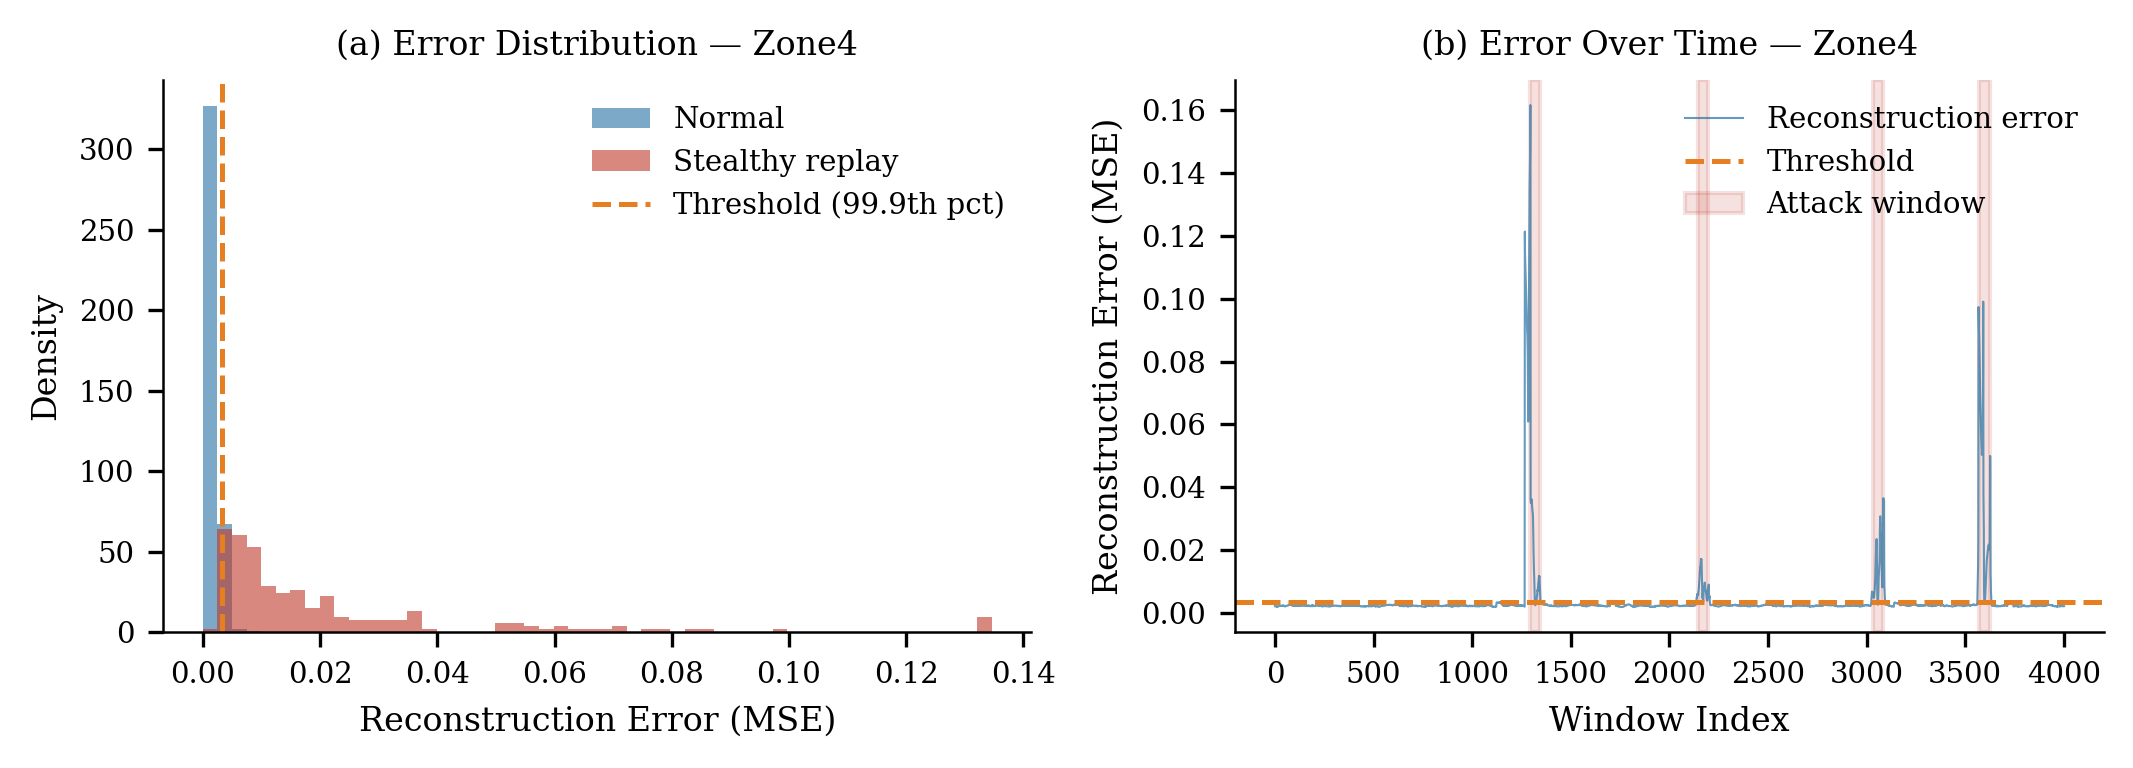

Saved: results/zone4_fig_detection.pdf


In [11]:
normal_errors = test_errors[y_test == 0]
attack_errors = test_errors[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.6))

# Panel A: error distribution
ax   = axes[0]
cap  = np.percentile(test_errors, 99.9)
bins = np.linspace(0, cap, 55)
ax.hist(normal_errors.clip(max=cap), bins=bins, density=True,
        alpha=0.6, color='#2471a3', label='Normal', linewidth=0)
ax.hist(attack_errors.clip(max=cap), bins=bins, density=True,
        alpha=0.6, color='#c0392b', label='Stealthy replay', linewidth=0)
ax.axvline(BEST_THRESHOLD, color='#e67e22', lw=1.2, ls='--',
           label=f'Threshold ({best_row["percentile"]}th pct)')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title(f'(a) Error Distribution — {ZONE_ID.title()}', fontsize=8)
ax.legend(frameon=False)

# Panel B: error over time with attack windows
ax2 = axes[1]
ax2.plot(test_errors, lw=0.5, color='#2471a3', alpha=0.7,
         label='Reconstruction error')
ax2.axhline(BEST_THRESHOLD, color='#e67e22', lw=1.2, ls='--',
            label='Threshold')

in_atk, start, first = False, 0, False
for i, lbl in enumerate(y_test):
    if lbl == 1 and not in_atk:
        start  = i
        in_atk = True
    elif lbl == 0 and in_atk:
        kw = dict(color='#c0392b', alpha=0.15)
        if not first:
            kw['label'] = 'Attack window'
            first = True
        ax2.axvspan(start, i, **kw)
        in_atk = False
if in_atk:
    ax2.axvspan(start, len(y_test), color='#c0392b', alpha=0.15)

ax2.legend(frameon=False)
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Reconstruction Error (MSE)')
ax2.set_title(f'(b) Error Over Time — {ZONE_ID.title()}', fontsize=8)

plt.tight_layout()
plt.savefig(f'results/{ZONE_ID}_fig_detection.pdf')
plt.savefig(f'results/{ZONE_ID}_fig_detection.png')
plt.show()
print(f'Saved: results/{ZONE_ID}_fig_detection.pdf')